In [37]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [21]:
df = pd.read_csv("titanic - titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [22]:
df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket'], inplace=True) 
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


In [23]:
df.shape

(418, 8)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    str    
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  418 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 26.3 KB


In [25]:
df.isnull().sum()

Survived     0
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [28]:
df[['Age', 'Fare']].describe()

,Age,Fare
count,332.000000,417.000000
mean,30.272590,35.627188
std,14.181209,55.907576
min,0.170000,0.000000
25%,21.000000,7.895800
50%,27.000000,14.454200
75%,39.000000,31.500000
max,76.000000,512.329200


In [29]:
cat_col = df.select_dtypes(include='str')

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [33]:
for i in cat_col:
    df[i] = le.fit_transform(df[i])

In [35]:
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,34.5,0,0,7.8292,1
1,1,3,0,47.0,1,0,7.0000,2


In [47]:
# IQR -> Inter quartile range

<Axes: xlabel='Age'>

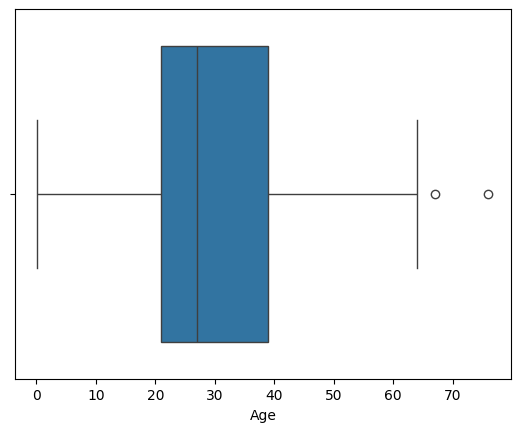

In [48]:
sns.boxplot(x = df['Age'])

In [49]:
q1 = df['Age'].quantile(0.25)
q2 = df['Fare'].quantile(0.75)

In [50]:
IQR = q2-q1

In [51]:
upper = q2 + 1.5*IQR
lower = q1 - 1.5*IQR

In [53]:
df = df[(df['Age']>lower) & (df['Age']<upper)]

<Axes: xlabel='Age'>

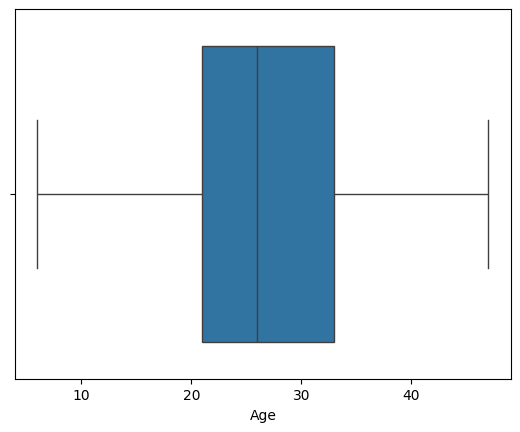

In [56]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='Fare'>

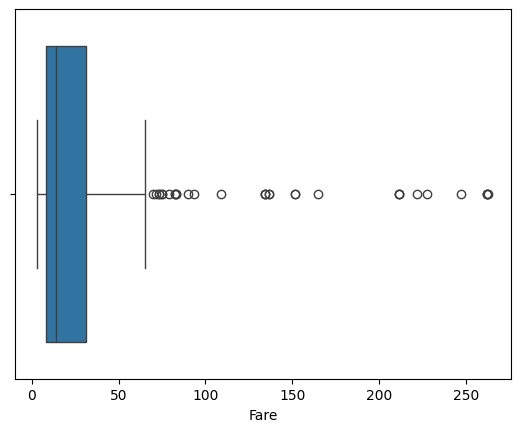

In [59]:
sns.boxplot(x = df['Fare'])

In [60]:
q1 = df['Fare'].quantile(0.25)
q2 = df['Fare'].quantile(0.75)

In [61]:
IQR = q2-q1

In [62]:
upper = q2 + 1.5*IQR
lower = q1 - 1.5*IQR

In [64]:
df['Fare'] = df['Fare'].clip(lower, upper)

<Axes: xlabel='Fare'>

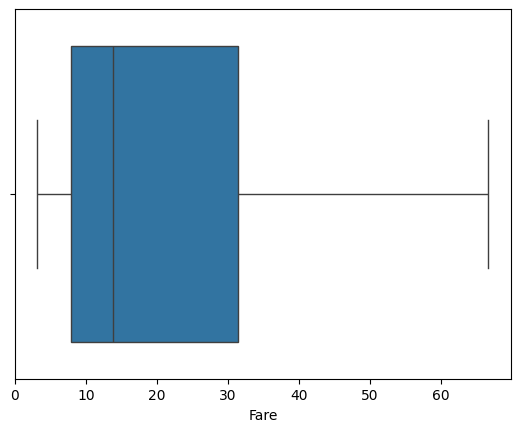

In [66]:
sns.boxplot(x = df['Fare'])

In [68]:
df.shape

(276, 8)

In [38]:
x = df.drop(columns=['Fare'])
y = df['Fare']

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)